In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# external imports
from pathlib import Path

In [3]:
from primaite.network.generator import NetworkGenerator

/home/sam/projects/PrimAITE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sam/projects/PrimAITE/.venv/lib/python3.10/site-packages/pydantic/_internal/_fields.py:161: UserWarning: Field "model_id" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
2024-08-30 10:50:33.859557: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-30 10:50:34.032767: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler f

In [4]:
# constants
NUMBER_OF_NODES = 30
RANDOM_SEED = 165116
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "do_nothing.yaml"
LAYDOWN_SAVE_PATH = Path("../data") / "laydown_configs" / "hey_buddy.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]

The `random_internet_as_graph` from `networkx` generates an undirected graph resembling the Internet AS network.

Node Types:
* T  -> tier-1
* M  -> mid-level
* C  -> customer
* CP -> content-provider

Each edge models an ADV communication link with a type and customer attribute.

[Here are the docs](https://networkx.org/documentation/stable/reference/generated/networkx.generators.internet_as_graphs.random_internet_as_graph.html#random-internet-as-graph)


In [5]:
generator = NetworkGenerator(training_config_path=TRAINING_CONFIG_PATH, random_seed=1729, services=SERVICE_NAMES, ports=PORTS_LIST)

In [6]:
import networkx as nx

G = nx.random_internet_as_graph(n=30)

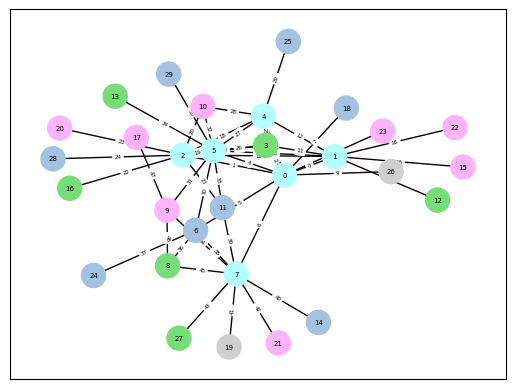

In [7]:
generator.show_network()

In [8]:
network = generator.network

In [9]:
network.nodes_table().head()

,Name,Hardware State,Software State,File System State,HTTP Service State,SSH Service State,FTP Service State
1,Node_0,-,GOOD,GOOD,GOOD,GOOD,GOOD
2,Node_1,-,GOOD,GOOD,GOOD,GOOD,GOOD
3,Node_2,BOOTING,GOOD,GOOD,GOOD,GOOD,GOOD
4,Node_3,ON,GOOD,GOOD,-,-,-
5,Node_4,RESETTING,GOOD,GOOD,GOOD,GOOD,GOOD


In [10]:
generator.links_dict["0"].source_node_id

'0'

In [11]:
network.traffic_table().head()

,Name,HTTP Traffic,SSH Traffic,FTP Traffic
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0


In [12]:
network.serialize()

[{'item_type': 'PORTS',
  'ports_list': [{'port': '80'}, {'port': '22'}, {'port': '21'}]},
 {'item_type': 'SERVICES',
  'service_list': [{'name': 'HTTP'}, {'name': 'SSH'}, {'name': 'FTP'}]},
 {'item_type': 'NODE',
  'node_id': '0',
  'name': 'Node_0',
  'node_class': 'SERVICE',
  'node_type': 'SERVER',
  'priority': 'P4',
  'hardware_state': 'NONE',
  'ip_address': '192.168.1.1',
  'software_state': 'GOOD',
  'file_system_state': 'GOOD',
  'services': [{'name': 'HTTP', 'port': '80', 'state': 'GOOD'},
   {'name': 'SSH', 'port': '22', 'state': 'GOOD'},
   {'name': 'FTP', 'port': '21', 'state': 'GOOD'}]},
 {'item_type': 'NODE',
  'node_id': '1',
  'name': 'Node_1',
  'node_class': 'SERVICE',
  'node_type': 'SERVER',
  'priority': 'P3',
  'hardware_state': 'NONE',
  'ip_address': '192.168.1.1',
  'software_state': 'GOOD',
  'file_system_state': 'GOOD',
  'services': [{'name': 'HTTP', 'port': '80', 'state': 'GOOD'},
   {'name': 'SSH', 'port': '22', 'state': 'GOOD'},
   {'name': 'FTP', 'port

In [13]:
network.save(LAYDOWN_SAVE_PATH)

# IERS

In [14]:
generator.generate_iers()
generator.generate_green_pols()
generator.generate_red_pols()
generator.generate_laydown(LAYDOWN_SAVE_PATH)

target nide id,  4
target nide id,  5
target nide id,  5
target nide id,  11
target nide id,  5


In [15]:
iers = generator.get_iers()
green_pols = generator.get_green_pols()
red_pols = generator.get_red_pols()
laydown = generator.laydown

In [16]:
iers[0].serialize()

{'item_type': 'RED_IER',
 'id': '0',
 'start_step': 99,
 'end_step': 111,
 'load': 10000,
 'protocol': 'HTTP',
 'port': ['80'],
 'source': '6',
 'destination': '24',
 'mission_criticality': 4}

In [17]:
green_pols[0].serialize()

{'item_type': 'GREEN_POL',
 'id': '0',
 'start_step': 103,
 'end_step': 106,
 'nodeId': '28',
 'type': 'SERVICE',
 'protocol': 'HTTP',
 'state': 'PATCHING'}

In [18]:
red_pols[0].serialize()

{'item_type': 'RED_POL',
 'id': '0',
 'start_step': 23,
 'end_step': 57,
 'nodeId': '4',
 'initiator': 'IER',
 'type': 'OPERATING',
 'protocol': 'HTTP',
 'state': 'SHUTTING_DOWN',
 'sourceNodeId': '0',
 'sourceNodeService': 'HTTP',
 'targetNodeId': '4',
 'sourceNodeServiceState': 'SHUTTING_DOWN'}

In [19]:
print(generator.network_description)


Nodes:
[
  {
    "Name":"Node_0",
    "Type":"SERVER"
  },
  {
    "Name":"Node_1",
    "Type":"SERVER"
  },
  {
    "Name":"Node_2",
    "Type":"SERVER"
  },
  {
    "Name":"Node_3",
    "Type":"LINK"
  },
  {
    "Name":"Node_4",
    "Type":"SERVER"
  },
  {
    "Name":"Node_5",
    "Type":"SERVER"
  },
  {
    "Name":"Node_6",
    "Type":"SWITCH"
  },
  {
    "Name":"Node_7",
    "Type":"SERVER"
  },
  {
    "Name":"Node_8",
    "Type":"LINK"
  },
  {
    "Name":"Node_9",
    "Type":"CCTV"
  },
  {
    "Name":"Node_10",
    "Type":"CCTV"
  },
  {
    "Name":"Node_11",
    "Type":"SWITCH"
  },
  {
    "Name":"Node_12",
    "Type":"LINK"
  },
  {
    "Name":"Node_13",
    "Type":"LINK"
  },
  {
    "Name":"Node_14",
    "Type":"SWITCH"
  },
  {
    "Name":"Node_15",
    "Type":"CCTV"
  },
  {
    "Name":"Node_16",
    "Type":"LINK"
  },
  {
    "Name":"Node_17",
    "Type":"CCTV"
  },
  {
    "Name":"Node_18",
    "Type":"SWITCH"
  },
  {
    "Name":"Node_19",
    "Type":"COMPUTER"
 

In [20]:
generator.question

'How many links is Node_1 connected to?'

In [21]:
generator.target_answer

'7'

In [23]:
from primaite.agents.gnn_agent import GNNAgent
from primaite.agents.simple import DoNothingNodeAgent
from primaite.primaite_session import PrimaiteSession

In [24]:
agent = PrimaiteSession(training_config_path=TRAINING_CONFIG_PATH, lay_down_config_path=LAYDOWN_SAVE_PATH)

In [25]:
agent.setup()

2024-08-30 10:51:37,627: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-08-30 10:51:37,675: Environment configuration loaded


{'end_step': 57, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'HTTP', 'sourceNodeId': '0', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'SHUTTING_DOWN', 'start_step': 23, 'state': 'SHUTTING_DOWN', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 92, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'HTTP', 'sourceNodeId': '4', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'PATCHING', 'start_step': 68, 'state': 'PATCHING', 'targetNodeId': '5', 'type': 'SERVICE'}
{'end_step': 85, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'HTTP', 'sourceNodeId': '2', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'NONE', 'start_step': 83, 'state': 'NONE', 'targetNodeId': '5', 'type': 'OS'}
{'end_step': 101, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '11', 'protocol': 'HTTP', 'sourceNodeId': '7', 'sourceNodeService': 'HTTP', 'sourceNodeServiceSt

2024-08-30 10:51:38,109: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7f451dea3280> observation component
2024-08-30 10:51:38,113: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-08-30 10:51:38,113: The output directory for this session is: /home/sam/primaite/2.0.1/sessions/2024-08-30/2024-08-30_10-51-37


<Figure size 640x480 with 0 Axes>

In [26]:
agent